In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
import matplotlib.pyplot as plt

# Load Data

In [22]:
df_O3 = pd.read_csv(Path("../data/processed/merged_o3_final.csv"))
df_PM10 = pd.read_csv(Path("../data/processed/merged_pm10_final.csv"))

In [23]:
df_PM10.isna().sum()

date                                      0
code_site                                 0
target_PM10                               1
avg_debit_Mean_days_last_4_weeks         63
avg_debit_last_15_days                    9
avg_taux_occup_Mean_days_last_4_weeks    63
avg_taux_occup_last_15_days               9
jour_semaine                              0
mois                                      0
numero_semaine                            0
concentration                             0
avg_debit                                 0
avg_taux_occup                            0
RR                                        0
TNTXM                                     0
FFM                                       0
previous_day                              9
previous_2w_mean                          1
next_RR                                   9
next_TNTXM                                9
next_FFM                                  9
dtype: int64

# Preprocessing

In [24]:
df_O3.drop(columns=[
    "avg_debit",
    "avg_taux_occup",    
    ],
    inplace = True
)

df_O3 = df_O3.rename(columns={
    'target_O3': 'Max_O3_J+1',
    'avg_debit_Mean_days_last_4_weeks': 'moy_trafic_4jsem',
    'avg_debit_last_15_days': 'moy_trafic_mois',
    'jour_semaine': 'jour_semaine_J+1',
    'mois': 'mois_J+1',
    'numero_semaine': 'semaine_J+1',
    'concentration':'Max_O3_J',
    'RR':"pluie_J",
    'TNTXM':'temp_J',
    'FFM':'vent_J',
    'previous_day':'Max_O3_J_1',
    'previous_2w_mean':'avg_max_O3_last_2w',
    'next_RR':'pluie_J+1',
    'next_TNTXM':'temp_J+1',
    'next_FFM':'vent_J+1'
})

df_O3["date"] = pd.to_datetime(df_O3["date"])
print(f"Dans df_O3, Les dates {df_O3[df_O3["moy_trafic_4jsem"].isna()]["date"].unique().tolist()} ont été retirées car certaines features basées sur des données du passé ou du futur ne peuvent pas être calculées à ces dates là")
df_O3.dropna(subset=["moy_trafic_4jsem", "pluie_J+1"], inplace=True)

df_PM10.drop(columns=[
    "avg_debit",
    "avg_taux_occup",    
    ],
    inplace = True
)

df_PM10 = df_PM10.rename(columns={
    'target_PM10': 'Moy_PM10_J+1',
    'avg_debit_Mean_days_last_4_weeks': 'moy_trafic_4jsem',
    'avg_debit_last_15_days': 'moy_trafic_mois',
    'jour_semaine': 'jour_semaine_J+1',
    'mois': 'mois_J+1',
    'numero_semaine': 'semaine_J+1',
    'concentration':'Moy_PM10_J',
    'RR':"pluie_J",
    'TNTXM':'temp_J',
    'FFM':'vent_J',
    'previous_day':'Moy_PM10_J_1',
    'previous_2w_mean':'avg_moy_PM10_last_2w',
    'next_RR':'pluie_J+1',
    'next_TNTXM':'temp_J+1',
    'next_FFM':'vent_J+1'
})

df_PM10["date"] = pd.to_datetime(df_PM10["date"])
print(f"Dans df_PM10, Les dates {df_PM10[df_PM10["moy_trafic_4jsem"].isna()]["date"].unique().tolist()} ont été retirées car certaines features basées sur des données du passé ou du futur ne peuvent pas être calculées à ces dates là")
df_PM10.dropna(subset=["moy_trafic_4jsem", "pluie_J+1"], inplace=True)

Dans df_O3, Les dates [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-02 00:00:00'), Timestamp('2021-01-03 00:00:00'), Timestamp('2021-01-04 00:00:00'), Timestamp('2021-01-05 00:00:00'), Timestamp('2021-01-06 00:00:00'), Timestamp('2021-01-07 00:00:00')] ont été retirées car certaines features basées sur des données du passé ou du futur ne peuvent pas être calculées à ces dates là
Dans df_PM10, Les dates [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-02 00:00:00'), Timestamp('2021-01-03 00:00:00'), Timestamp('2021-01-04 00:00:00'), Timestamp('2021-01-05 00:00:00'), Timestamp('2021-01-06 00:00:00'), Timestamp('2021-01-07 00:00:00')] ont été retirées car certaines features basées sur des données du passé ou du futur ne peuvent pas être calculées à ces dates là


In [25]:
df_O3

,date,code_site,Max_O3_J+1,moy_trafic_4jsem,moy_trafic_mois,avg_taux_occup_Mean_days_last_4_weeks,avg_taux_occup_last_15_days,jour_semaine_J+1,mois_J+1,semaine_J+1,Max_O3_J,pluie_J,temp_J,vent_J,Max_O3_J_1,avg_max_O3_last_2w,pluie_J+1,temp_J+1,vent_J+1
7,2021-01-08,FR04004,25.9,536.752177,723.625589,3.314645,5.937506,5,1,1,29.3,0.000000,2.850000,2.166667,23.6,15.628571,0.000000,1.433333,4.433333
8,2021-01-09,FR04004,37.4,655.339084,743.788408,5.302376,6.171570,6,1,1,27.5,0.000000,1.433333,4.433333,29.3,17.337500,0.155556,1.716667,2.933333
9,2021-01-10,FR04004,38.0,620.688433,742.978074,4.444679,6.298423,0,1,2,37.4,0.155556,1.716667,2.933333,27.5,18.466667,0.733333,2.850000,4.066667
10,2021-01-11,FR04004,53.4,761.145615,734.306530,6.530538,6.219338,1,1,2,39.8,0.733333,2.850000,4.066667,37.4,20.360000,5.500000,7.033333,6.066667
11,2021-01-12,FR04004,64.0,826.537981,741.188821,7.219007,6.322344,2,1,2,53.4,5.500000,7.033333,6.066667,39.8,22.127273,2.188889,7.666667,5.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4350,2023-12-26,FR04055,48.4,503.502793,501.183963,8.331803,7.766061,2,12,52,73.6,0.150000,10.666667,4.400000,71.0,53.564286,0.100000,9.550000,6.466667
4351,2023-12-27,FR04055,51.6,525.145173,496.062105,8.632966,7.650744,3,12,52,48.8,0.100000,9.550000,6.466667,73.6,54.800000,0.000000,10.500000,5.300000
4352,2023-12-28,FR04055,63.6,537.098426,492.070901,9.232061,7.498194,4,12,52,54.3,0.000000,10.500000,5.300000,48.8,54.121429,0.400000,10.433333,6.500000
4353,2023-12-29,FR04055,55.9,553.408191,489.195102,8.677833,7.365568,5,12,52,63.6,0.400000,10.433333,6.500000,54.3,55.200000,0.900000,9.216667,6.066667


# Feature Engineering

## Transformation de la target en variable binaire

In [26]:
SEUIL_O3 = 130
SEUIL_PM10 = 50

df_O3['y'] = (df_O3['Max_O3_J+1'] > SEUIL_O3).astype(int)
df_PM10['y'] = (df_PM10['Moy_PM10_J+1'] > SEUIL_PM10).astype(int)

nb_lignes_O3 = len(df_O3.axes[0])
nb_pics_O3 = df_O3['y'].sum()
nb_non_pics_O3 = nb_lignes_O3 - nb_pics_O3
perc_pics_O3 = 100 * (nb_pics_O3 / nb_lignes_O3)

nb_lignes_PM10 = len(df_O3.axes[0])
nb_pics_PM10 = df_PM10['y'].sum()
nb_non_pics_PM10 = nb_lignes_PM10 - nb_pics_PM10
perc_pics_PM10 = 100 * (nb_pics_PM10 / nb_lignes_PM10)

print(f"Pour O3 entre 2021 et 2023, il y a {nb_pics_O3} pics VS {nb_non_pics_O3} non-pics, soit {np.round(perc_pics_O3, 2)}% de pics")
print(f"Pour PM10 entre 2021 et 2023, il y a {nb_pics_PM10} pics VS {nb_non_pics_PM10} non-pics, soit {np.round(perc_pics_PM10, 2)}% de pics")

Pour O3 entre 2021 et 2023, il y a 146 pics VS 4178 non-pics, soit 3.38% de pics
Pour PM10 entre 2021 et 2023, il y a 238 pics VS 4086 non-pics, soit 5.5% de pics


## Encodage des variables caétégorielles

Certains modèles comme la régression logistique ne fonctionnent pas avec des variables catégorielles

In [27]:
le = LabelEncoder()
df_O3["code_site_enc"] = le.fit_transform(df_O3["code_site"])
df_PM10["code_site_enc"] = le.fit_transform(df_PM10["code_site"])

## Selection des features

In [28]:
features_O3 = [col for col in df_O3.columns if col not in ['date', 'Max_O3_J+1', 'code_site', 'y']]
features_PM10 = [col for col in df_PM10.columns if col not in ['date', 'Moy_PM10_J+1', 'code_site', 'y']]

# Train Test Split temporel (2021-2022 VS 2023)

In [29]:
train_O3 = df_O3[df_O3['date'].dt.year.isin([2021, 2022])]
test_O3  = df_O3[df_O3['date'].dt.year == 2023]

X_train_O3 = train_O3[features_O3]
y_train_O3 = train_O3['y']
X_test_O3  = test_O3[features_O3]
y_test_O3  = test_O3['y']

train_PM10 = df_PM10[df_PM10['date'].dt.year.isin([2021, 2022])]
test_PM10  = df_PM10[df_PM10['date'].dt.year == 2023]

X_train_PM10 = train_PM10[features_PM10]
y_train_PM10 = train_PM10['y']
X_test_PM10  = test_PM10[features_PM10]
y_test_PM10  = test_PM10['y']

# Decision Tree

On commence par un arbre de décision tout simple pour visualiser les features qui influencent le modèle

In [30]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        random_state=42,
        max_depth=10
        ))
])

## Train & Predict

In [31]:
pipeline_O3 = clone(pipeline)
pipeline_PM10 = clone(pipeline)

pipeline_O3.fit(X_train_O3, y_train_O3)
pipeline_PM10.fit(X_train_PM10, y_train_PM10)

clf_O3 = pipeline_O3.named_steps['clf']
clf_PM10 = pipeline_PM10.named_steps['clf']

y_pred_O3 = pipeline_O3.predict(X_test_O3)
y_pred_PM10 = pipeline_PM10.predict(X_test_PM10)

In [32]:
# O3
recall_O3 = recall_score(y_test_O3, y_pred_O3, pos_label=1)
precision_O3 = precision_score(y_test_O3, y_pred_O3, pos_label=1)
f1_O3 = f1_score(y_test_O3, y_pred_O3, pos_label=1)

print(f"O3 - Recall classe positive (pics) : {recall_O3:.2f}")
print(f"O3 - Precision classe positive (pics) : {precision_O3:.2f}")
print(f"O3 - f1-score classe positive (pics) : {f1_O3:.2f}\n")

# PM10
recall_PM10 = recall_score(y_test_PM10, y_pred_PM10, pos_label=1)
precision_PM10 = precision_score(y_test_PM10, y_pred_PM10, pos_label=1)
f1_PM10 = f1_score(y_test_PM10, y_pred_PM10, pos_label=1)

print(f"PM10 - Recall classe positive (pics) : {recall_PM10:.2f}")
print(f"PM10 - Precision classe positive (pics) : {precision_PM10:.2f}")
print(f"PM10 - f1-score classe positive (pics) : {f1_PM10:.2f}\n")

O3 - Recall classe positive (pics) : 0.27
O3 - Precision classe positive (pics) : 0.39
O3 - f1-score classe positive (pics) : 0.32

PM10 - Recall classe positive (pics) : 0.48
PM10 - Precision classe positive (pics) : 0.38
PM10 - f1-score classe positive (pics) : 0.43



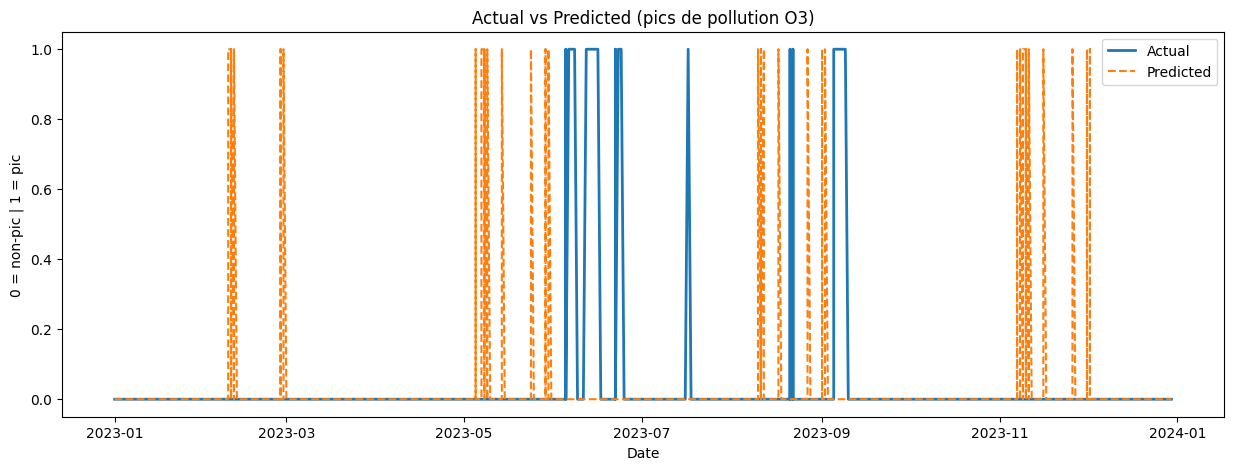

In [33]:
df_plot = test_O3.copy()
df_plot = df_plot.sort_values("date")

df_plot["y_pred"] = y_pred_O3

plt.figure(figsize=(15,5))
plt.plot(df_plot["date"], df_plot["y"], label="Actual", linewidth=2)
plt.plot(df_plot["date"], df_plot["y_pred"], label="Predicted", linestyle="--")

plt.legend()
plt.title("Actual vs Predicted (pics de pollution O3)")
plt.xlabel("Date")
plt.ylabel("0 = non-pic | 1 = pic")

plt.show()

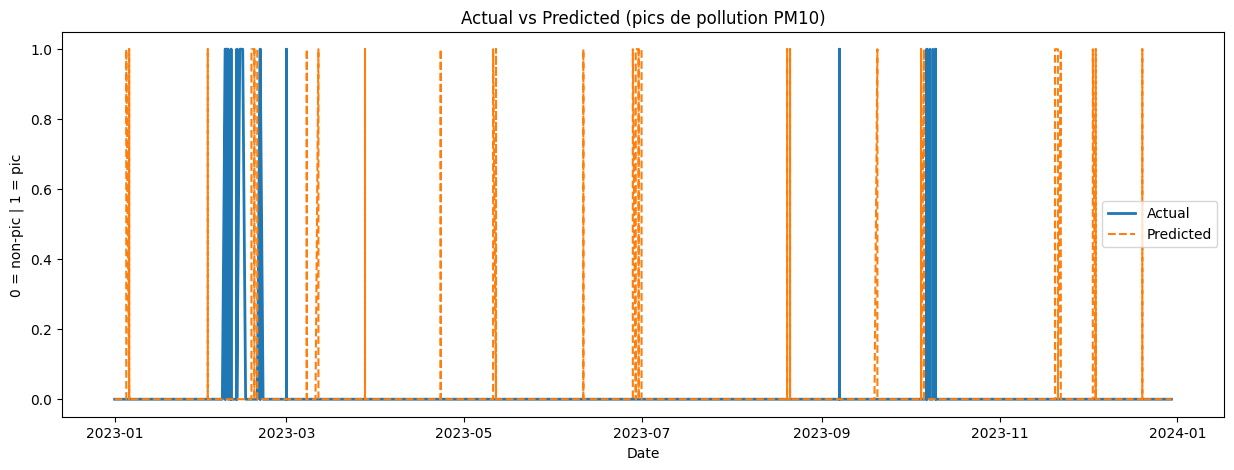

In [34]:
df_plot = test_PM10.copy()
df_plot = df_plot.sort_values("date")

df_plot["y_pred"] = y_pred_PM10

plt.figure(figsize=(15,5))
plt.plot(df_plot["date"], df_plot["y"], label="Actual", linewidth=2)
plt.plot(df_plot["date"], df_plot["y_pred"], label="Predicted", linestyle="--")

plt.legend()
plt.title("Actual vs Predicted (pics de pollution PM10)")
plt.xlabel("Date")
plt.ylabel("0 = non-pic | 1 = pic")

plt.show()

Arbre pour O3


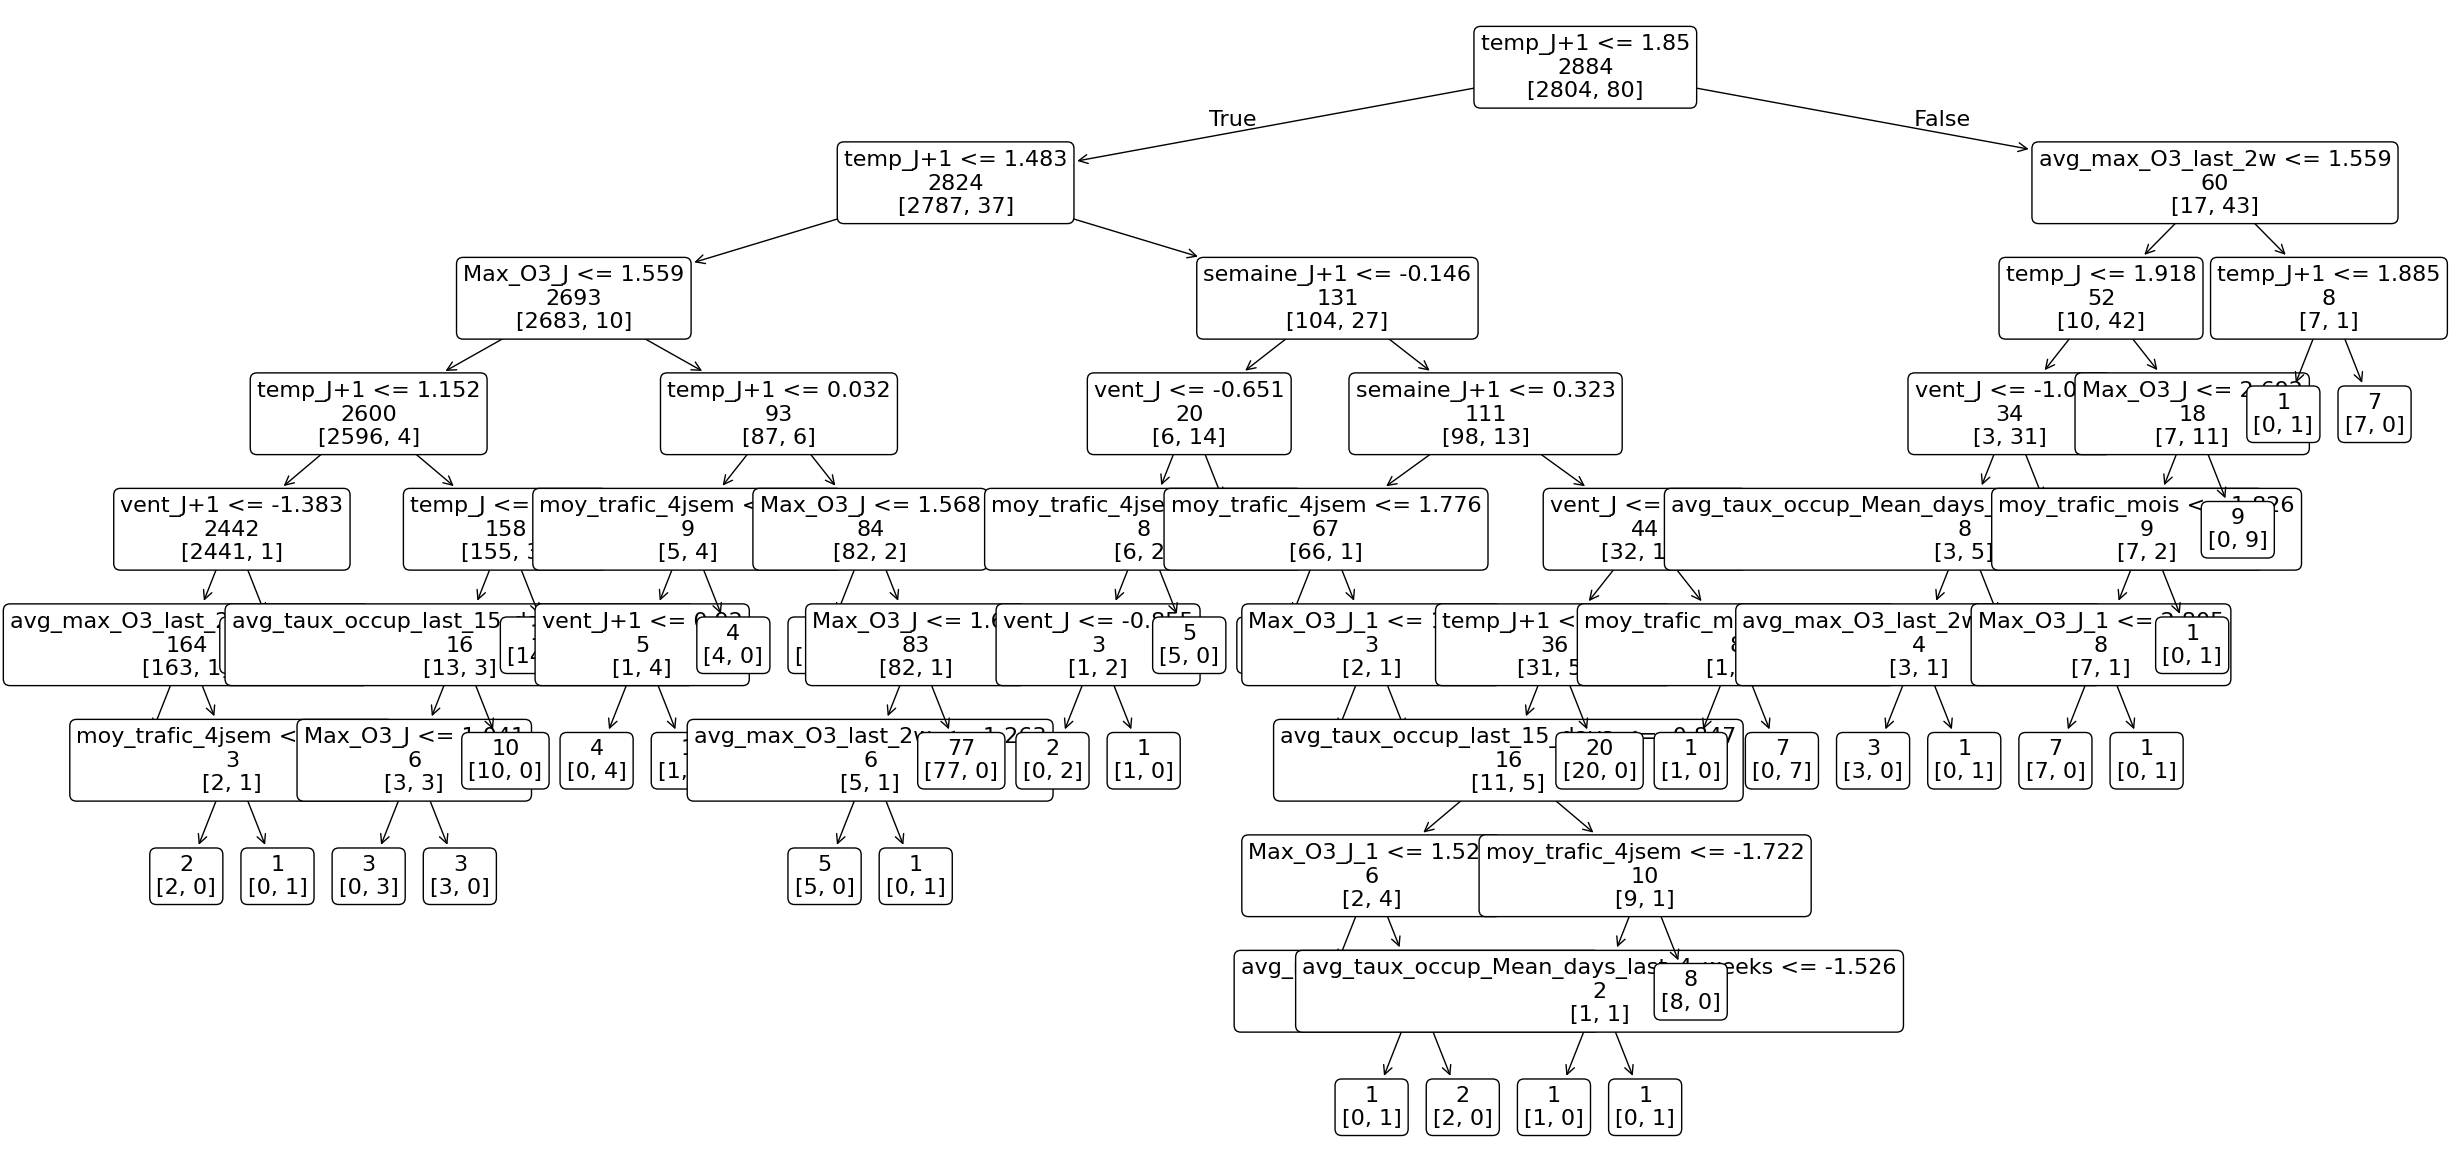

In [35]:
plt.figure(figsize=(30,15))  # plus grand
tree.plot_tree(
    clf_O3,
    feature_names=features_O3,
    filled=False,
    rounded=True,
    impurity=False,
    label='none',
    fontsize=16
)
print("Arbre pour O3")
plt.show()

arbre pour PM10


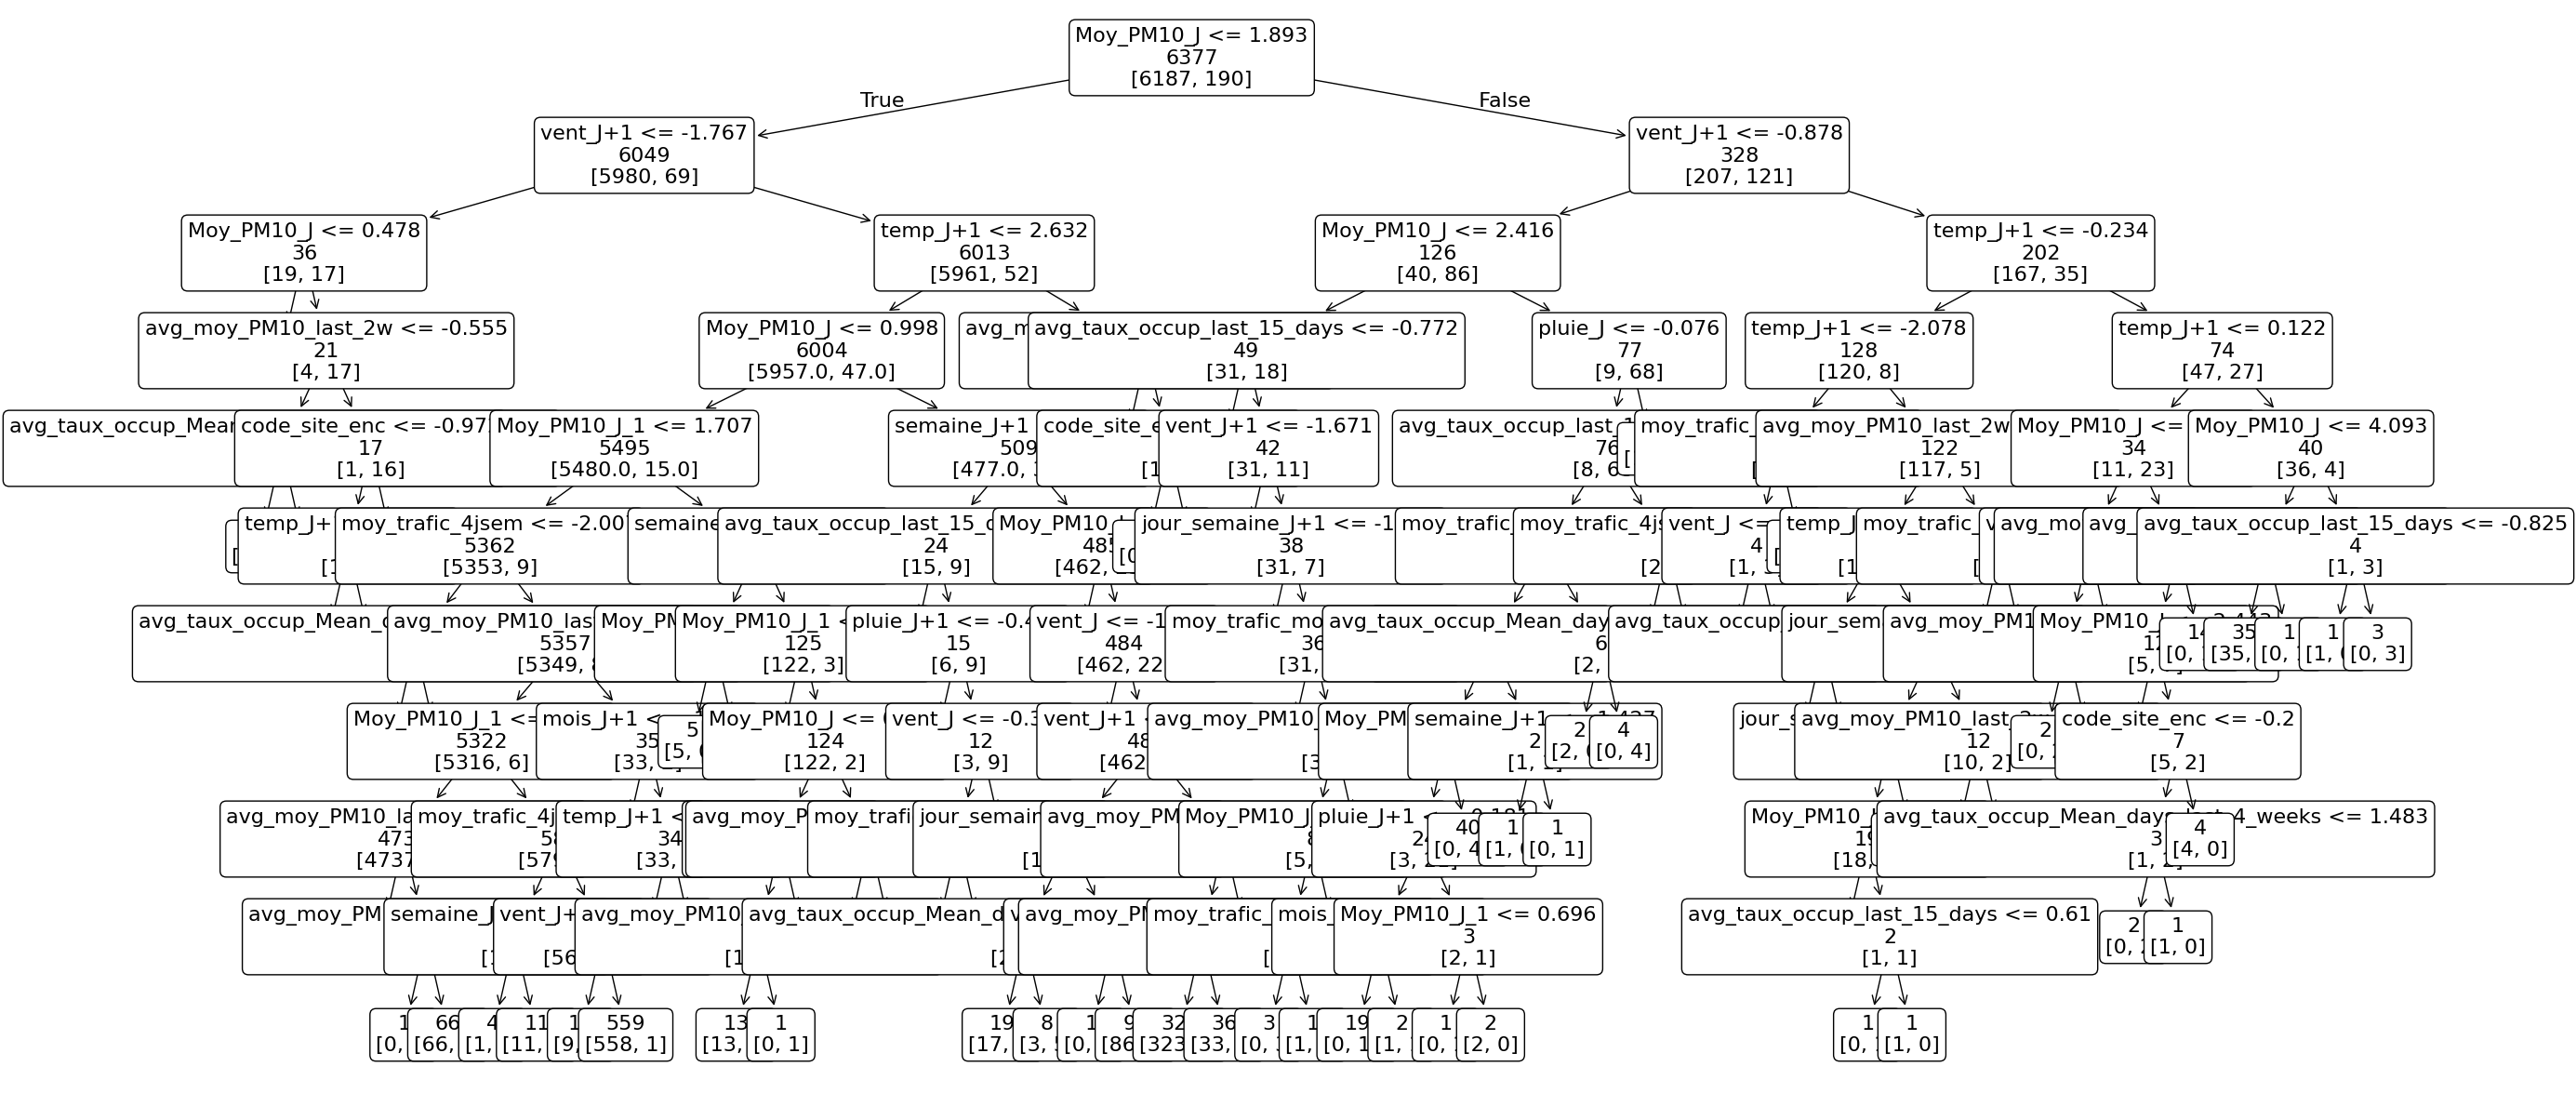

In [36]:
plt.figure(figsize=(30,15))
tree.plot_tree(
    clf_PM10,
    feature_names=features_PM10,
    filled=False,
    rounded=True,
    impurity=False,
    label='none',
    fontsize=16
)
print("arbre pour PM10")
plt.show()

# Comparaison multi-modèles

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [38]:
def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
0  Logistic Regression    0.393939       0.742857  0.514851
3        Random Forest    0.348485       0.766667  0.479167
4              XGBoost    0.287879       0.655172  0.400000
2                  SVM    0.196970       1.000000  0.329114
1        Decision Tree    0.272727       0.391304  0.321429

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.520833       0.757576  0.617284
0  Logistic Regression    0.500000       0.648649  0.564706
1        Decision Tree    0.479167       0.383333  0.425926
3        Random Forest    0.270833       0.928571  0.419355
2                  SVM    0.208333       0.909091  0.338983


A ce stade, les performances sont mauvaises quelque soit le modèle

# Gestion du déséquilibre

Nos données sont très déséquilibrées : ~3% et ~5% de classe positive resp. pour O3 et PM10.
Explorons différentes méthodes pour gérer ce déséquilibre et ainsi tenter d'améliorer les performances du modèle. 

## Undersampling

In [39]:
def undersample(df, target_col):
    df_pos = df[df[target_col] == 1]
    df_neg = df[df[target_col] == 0]
    df_neg_sampled = df_neg.sample(n=len(df_pos), random_state=42)
    df_balanced = pd.concat([df_pos, df_neg_sampled])
    return df_balanced.sample(frac=1, random_state=42)

train_O3_balanced = undersample(train_O3, 'y')
X_train_O3_bal = train_O3_balanced[features_O3]
y_train_O3_bal = train_O3_balanced['y']

train_PM10_balanced = undersample(train_PM10, 'y')
X_train_PM10_bal = train_PM10_balanced[features_PM10]
y_train_PM10_bal = train_PM10_balanced['y']

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

results_O3 = evaluate_models(X_train_O3_bal, y_train_O3_bal, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10_bal, y_train_PM10_bal, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.863636       0.337278  0.485106
0  Logistic Regression    0.939394       0.314721  0.471483
3        Random Forest    0.939394       0.313131  0.469697
1        Decision Tree    0.939394       0.289720  0.442857
2                  SVM    0.954545       0.260331  0.409091

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
3        Random Forest    0.958333       0.282209  0.436019
4              XGBoost    0.916667       0.282051  0.431373
2                  SVM    0.875000       0.269231  0.411765
0  Logistic Regression    0.958333       0.220096  0.357977
1        Decision Tree    0.937500       0.185950  0.310345


/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Pondération des classes

In [40]:
models_weighted_class = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    
    # XGBoost ne prend pas class_weight directement
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight = (len(y_train_O3) - sum(y_train_O3)) / sum(y_train_O3)
    )
}

In [41]:
def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models_weighted_class.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
2                  SVM    0.621212       0.455556  0.525641
0  Logistic Regression    0.939394       0.356322  0.516667
4              XGBoost    0.363636       0.648649  0.466019
1        Decision Tree    0.333333       0.323529  0.328358
3        Random Forest    0.045455       0.375000  0.081081

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.625000       0.697674  0.659341
2                  SVM    0.666667       0.438356  0.528926
1        Decision Tree    0.520833       0.301205  0.381679
0  Logistic Regression    0.916667       0.231579  0.369748
3        Random Forest    0.229167       0.846154  0.360656


/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Implémentation de SMOTE

Etant donné que les classes sont très déséquilibrées, nous implémentons une technique de génération artificielle de données afin d'avoir plus d'exemples sur la classe positive.

In [42]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [43]:
def evaluate_models_smote(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models_weighted_class.items():
        
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)   

In [44]:
results_o3_smote = evaluate_models_smote(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_pm10_smote = evaluate_models_smote(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 avec SMOTE ===")
print(results_o3_smote)

print("\n=== PM10 avec SMOTE ===")
print(results_pm10_smote)

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 avec SMOTE ===
                 model  recall_pic  precision_pic  f1_score
0  Logistic Regression    0.939394       0.436620  0.596154
2                  SVM    0.348485       0.338235  0.343284
1        Decision Tree    0.439394       0.256637  0.324022
4              XGBoost    0.333333       0.282051  0.305556
3        Random Forest    0.181818       0.230769  0.203390

=== PM10 avec SMOTE ===
                 model  recall_pic  precision_pic  f1_score
2                  SVM    0.625000       0.454545  0.526316
3        Random Forest    0.562500       0.442623  0.495413
4              XGBoost    0.791667       0.355140  0.490323
0  Logistic Regression    0.916667       0.289474  0.440000
1        Decision Tree    0.666667       0.244275  0.357542


/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:21:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Changement de seuil simple

In [47]:
def evaluate_models_threshold(X_train, y_train, X_test, y_test):
    
    results = []
    thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        beta = 1.2
        
        for threshold in thresholds:
            y_pred = (y_proba > threshold).astype(int)
            
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            fbeta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)
            
            results.append({
                "model": name,
                "threshold": threshold,
                "recall_pic": recall,
                "precision_pic": precision,
                "f1_score": f1,
                "fbeta_score": fbeta
            })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

In [48]:
results_O3_threshold = evaluate_models_threshold(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10_threshold = evaluate_models_threshold(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("=== O3 avec seuils ===")
print(results_O3_threshold)

print("\n=== PM10 avec seuils ===")
print(results_PM10_threshold)

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 avec seuils ===
                  model  threshold  recall_pic  precision_pic  f1_score  fbeta_score
0   Logistic Regression        0.2    0.803030       0.679487  0.736111     0.747342
1   Logistic Regression        0.3    0.712121       0.712121  0.712121     0.712121
10                  SVM        0.2    0.681818       0.714286  0.697674     0.694761
11                  SVM        0.3    0.651515       0.741379  0.693548     0.685572
12                  SVM        0.4    0.545455       0.765957  0.637168     0.618417
2   Logistic Regression        0.4    0.560606       0.711538  0.627119     0.613983
16        Random Forest        0.3    0.575758       0.666667  0.617886     0.609840
15        Random Forest        0.2    0.681818       0.529412  0.596026     0.609864
13                  SVM        0.5    0.469697       0.794872  0.590476     0.564309
14                  SVM        0.6    0.424242       0.800000  0.554455     0.525377
17        Random Forest        0.4    0.43

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:22:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Changement de seuil avec SMOTE

L'ajout de SMOTE influençant la prédiction de la classe positive, on améliore le recall mais on perd en précision par rapport à un changement de seuil classique.

In [31]:
def evaluate_models_smote_threshold(X_train, y_train, X_test, y_test):
    
    results = []
    thresholds = [0.2, 0.3, 0.4, 0.5]
    
    for name, model in models_weighted_class.items():
        
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        
        # Probability
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        for threshold in thresholds:
            
            y_pred = (y_proba > threshold).astype(int)
            
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({
                "model": name,
                "threshold": threshold,
                "recall_pic": recall,
                "precision_pic": precision,
                "f1_score": f1
            })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

In [32]:
results_o3_smote_threshold = evaluate_models_smote_threshold(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_pm10_smote_threshold = evaluate_models_smote_threshold(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 avec SMOTE et seuils ===")
print(results_o3_smote_threshold)

print("\n=== PM10 avec SMOTE et seuils ===")
print(results_pm10_smote_threshold)

/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:04:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/pierre-farsa/air-quality/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:04:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 avec SMOTE et seuils ===
                  model  threshold  recall_pic  precision_pic  f1_score
3   Logistic Regression        0.5    0.939394       0.392405  0.553571
2   Logistic Regression        0.4    0.939394       0.340659  0.500000
12        Random Forest        0.2    0.621212       0.362832  0.458101
1   Logistic Regression        0.3    0.939394       0.298077  0.452555
0   Logistic Regression        0.2    0.969697       0.264463  0.415584
16              XGBoost        0.2    0.439394       0.333333  0.379085
17              XGBoost        0.3    0.363636       0.307692  0.333333
18              XGBoost        0.4    0.348485       0.302632  0.323944
13        Random Forest        0.3    0.303030       0.270270  0.285714
19              XGBoost        0.5    0.287879       0.263889  0.275362
8                   SVM        0.2    0.242424       0.296296  0.266667
14        Random Forest        0.4    0.242424       0.266667  0.253968
9                   SVM        0

## Biais moyen

In [37]:
# Exemple pour O3
y_proba_O3 = pipeline_O3.predict_proba(X_test_O3)[:, 1]  # Probabilité de classe 1 (pic)
y_true_O3 = y_test_O3.values

In [38]:
# Biais moyen = moyenne des différences entre prédictions et vérité
mean_bias_O3 = np.mean(y_proba_O3 - y_true_O3)
print(f"Biais moyen O3 : {mean_bias_O3:.3f}")

Biais moyen O3 : -0.014
